# Data Generation

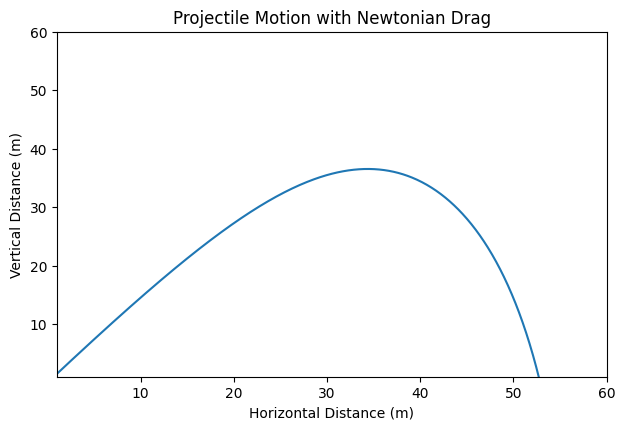

In [180]:
import numpy as np
import matplotlib.pyplot as plt

g = 9.81  # Acceleration due to gravity (m/s^2)
rho = 1.225  # Air density (kg/m^3)
Cd = 0.47  # Drag coefficient
A = 0.01  # Cross-sectional area (m^2)
m = 0.1  # Mass of the projectile (kg)
mu = 0.5 * rho * Cd * A

def runge_kutta_4th_order(f, x0, y0, h, n):
    x_vals = [x0]
    y_vals = [y0]
    for _ in range(n):
        k1 = h * f(x_vals[-1], y_vals[-1])
        k2 = h * f(x_vals[-1] + h / 2, y_vals[-1] + k1 / 2)
        k3 = h * f(x_vals[-1] + h / 2, y_vals[-1] + k2 / 2)
        k4 = h * f(x_vals[-1] + h, y_vals[-1] + k3)

        x_vals.append(x_vals[-1] + h)
        y_vals.append(y_vals[-1] + (k1 + 2 * k2 + 2 * k3 + k4) / 6)
    return np.array(x_vals), np.array(y_vals)

def projectile_motion_with_drag(t, u):
    x,vx, y, vy = u


    v = np.sqrt(vx**2 + vy**2)
    Fx = -mu * v * vx
    Fy = -mu * v * vy

    dxdt = vx
    dvxdt = (Fx / m)
    dydt = vy
    dvydt = (Fy / m) - g

    return np.array([dxdt, dvxdt, dydt, dvydt])

# Initial conditions
x0 = 0.0
y0 = 0.0
vx0 = 40.0
vy0 = 60.0

u0 = np.array([x0,vx0, y0,vy0])

# Time settings
t0 = 0.0
h = 0.01  # Step size
num_steps = 541

# Solve the system of ODEs using Runge-Kutta 4th order
time_vals, state_vals = runge_kutta_4th_order(projectile_motion_with_drag, t0, u0, h, num_steps)

# Extract position, velocity, and acceleration values
x_vals = state_vals[:, 0]
vx_vals = state_vals[:, 1]
y_vals = state_vals[:, 2]
vy_vals = state_vals[:, 3]

# Calculate acceleration components ax and ay
ax_vals = (-mu * vx_vals * np.sqrt(vx_vals**2 + vy_vals**2)) / m
ay_vals = (-mu * vy_vals * np.sqrt(vx_vals**2 + vy_vals**2)) / m - g

# Choose 100 random indices from both arrays
random_indices = np.random.choice(541, size=3, replace=False)

# Use np.pick to select entries from the arrays using the random indices
time_vals_rnd = time_vals[random_indices]
state_vals_rnd = state_vals[random_indices]

# Calculate velocity magnitude v
v_vals = np.sqrt(vx_vals**2 + vy_vals**2)

# Calculate acceleration magnitude a
a_vals = np.sqrt(ax_vals**2 + ay_vals**2)

# Plot the trajectory, velocity, and acceleration
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(x_vals, y_vals)
plt.title("Projectile Motion with Newtonian Drag")
plt.xlabel("Horizontal Distance (m)")
plt.ylabel("Vertical Distance (m)")
plt.xlim(1, 60)
plt.ylim(1, 60)
plt.grid(False)

plt.tight_layout()
plt.show()


# Library import

In [263]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


# physics background

This PINN aims to simulate the trajectorie of a projectile slowed down by a drag force.

The the magnitude of the force is depedend on the following Parmeters:
1. rho the Air density (kg/m^3), 
2. Cd the drag coefficient, 
3. A the Cross-sectional area (m^2)

all these parameters can be summerized to one coefficiant:
- mu = 0.5 * rho * Cd * A

Furthermore is the drag force dependant on the square of the projectiles speed:
- F = mu * v * |v| 
where F can be split up in a x and a y component:
- Fx = mu * vx * |v| and 
- Fy = mu * vy * |v|

The resulting differential equations describe the path of the projectile:
- ax = Fx/m
- ay = Fy/m - g 

where m is the Mass of the projectile (kg) and g the earths gravitational acceleration

# Data import

In [264]:
#import the true solution
t_sol = torch.tensor(time_vals, dtype=torch.float32).unsqueeze(1)
x_sol = torch.tensor(state_vals[:,0], dtype=torch.float32).unsqueeze(1)
y_sol = torch.tensor(state_vals[:,2], dtype=torch.float32).unsqueeze(1)

#extract random data points for training
t_sol_rnd = torch.tensor(time_vals_rnd, dtype=torch.float32).unsqueeze(1)
x_sol_rnd = torch.tensor(state_vals_rnd[:,0], dtype=torch.float32).unsqueeze(1)
y_sol_rnd = torch.tensor(state_vals_rnd[:,2], dtype=torch.float32).unsqueeze(1)

#create colocation points for the physics loss
t_colocation = torch.linspace(0, 5.41, 50).reshape(-1, 1)  

# create PINN model

In [290]:
class PINN(nn.Module):
    def __init__(self):
        """
        Define the Physics-Informed Neural Network (PINN) model.
        
        This class defines the architecture of the PINN model, which is designed
        to solve differential equations while incorporating physics-based constraints.
        The model consists of several layers, each contributing to capturing complex
        relationships in the data. The following steps outline the process:
        
        1. Initialize the PINN model as a subclass of nn.Module.
        2. Configure the layers and connections within the model architecture,
           including fully connected layers (fc1, fc2) and output layers (fc_x, fc_y).
        3. Define the forward pass mechanism for the model, where input data flows
           through the layers to produce predicted outputs.
        
        Args:
            None
            
        Attributes:
            fc1 (nn.Linear): First fully connected layer.
            fc2 (nn.Linear): Second fully connected layer.
            fc_x (nn.Linear): Output layer for x-coordinate prediction.
            fc_y (nn.Linear): Output layer for y-coordinate prediction.
        
        Returns:
            None
        """
        super(PINN, self).__init__()
        
        # Step 2: Configure model architecture (layers and connections)
        self.fc1 = nn.Linear(1, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc_x = nn.Linear(64, 1)
        self.fc_y = nn.Linear(64, 1)
    
    def forward(self, x):
        """
        Perform a forward pass through the PINN model.
        
        This method defines the forward pass mechanism of the PINN model, where
        the input data x is processed through the layers to produce predicted
        outputs for both x-coordinate (x_output) and y-coordinate (y_output).
        
        Args:
            x (Tensor): Input data tensor.
            
        Returns:
            Tuple[Tensor, Tensor]: Predicted x and y coordinates.
        """
        
        dtype = self.fc1.weight.dtype
        
        # Apply the first fully connected layer with GELU activation
        x = torch.nn.functional.gelu(self.fc1(x.to(dtype)))
        
        # Apply the second fully connected layer with GELU activation
        x = torch.nn.functional.gelu(self.fc2(x.to(dtype)))
        
        # Produce predicted x and y coordinates using output layers
        x_output = self.fc_x(x)  # Predicted x-coordinate
        y_output = self.fc_y(x)  # Predicted y-coordinate

        return x_output, y_output
    

# Physicis informed loss

In [291]:
physics_informed_loss.__doc__

'\n    Define the physics-informed loss for the PINN model.\n    \n    This function calculates the loss used to incorporate the underlying physics\n    principles into the PINN. The following steps are involved:\n    \n    1. Enable gradient computation for the colocation points tensor, t_colocation.\n    2. Predict x and y values by calling the neural network model.\n    3. Compute the first gradients dx_dt and dy_dt, and second gradients d2x_dt2\n       and d2y_dt2, using the torch.autograd.grad command\n       (see [torch.autograd.grad](https://pytorch.org/docs/stable/generated/torch.autograd.grad.html)).\n    4. Calculate the speed v using the Euclidean norm of the vector [dx_dt, dy_dt].\n    5. Define the differential equation residuals for both x and y components.\n       (see [residuals](https://www.displayr.com/learn-what-are-residuals/))\n    6. Calculate the mean squared residuals for both x and y using torch.mean().\n       (see [torch.mean()](https://pytorch.org/docs/stabl

In [292]:
def physics_informed_loss(model, t_colocation):
    """
    Define the physics-informed loss for the PINN model.
    
    This function calculates the loss used to incorporate the underlying physics
    principles into the PINN. The following steps are involved:
    
    1. Enable gradient computation for the colocation points tensor, t_colocation.
    2. Predict x and y values by calling the neural network model.
    3. Compute the first gradients dx_dt and dy_dt, and second gradients d2x_dt2
       and d2y_dt2, using the torch.autograd.grad command
       (see [torch.autograd.grad](https://pytorch.org/docs/stable/generated/torch.autograd.grad.html)).
    4. Calculate the speed v using the Euclidean norm of the vector [dx_dt, dy_dt].
    5. Define the differential equation residuals for both x and y components.
       (see [residuals](https://www.displayr.com/learn-what-are-residuals/))
    6. Calculate the mean squared residuals for both x and y using torch.mean().
       (see [torch.mean()](https://pytorch.org/docs/stable/generated/torch.mean.html))
    7. Return the combined physics-informed loss as the sum of loss_x and loss_y.
    
    Args:
        model (nn.Module): The physics-informed neural network model.
        t_colocation (torch.Tensor): Colocation points tensor with requires_grad=True.
        
    Returns:
        torch.Tensor: The combined physics-informed loss.
    """
    # Step 1: Enable gradient computation for t_colocation
    t_colocation.requires_grad = True
    
    # Step 2: Predict x and y values using the neural network model
    x_pred, y_pred = model(t_colocation)
    
    # Step 3: Compute first and second gradients
    dx_dt = torch.autograd.grad(torch.sum(x_pred), t_colocation, create_graph=True)[0]
    d2x_dt2 = torch.autograd.grad(torch.sum(dx_dt), t_colocation, create_graph=True)[0]
    
    dy_dt = torch.autograd.grad(torch.sum(y_pred), t_colocation, create_graph=True)[0]
    d2y_dt2 = torch.autograd.grad(torch.sum(dy_dt), t_colocation, create_graph=True)[0]
    
    # Step 4: Calculate the speed v using the Euclidean norm
    v = torch.sqrt(dx_dt ** 2 + dy_dt ** 2)
    Fx = -mu * v * dx_dt
    Fy = -mu * v * dy_dt
    
    # Step 5: Define differential equation residuals
    residual_x = d2x_dt2 - Fx / m
    residual_y = d2y_dt2 - ((Fy / m) - g)
    
    # Step 6: Calculate mean squared residuals
    loss_x = torch.mean(residual_x ** 2)
    loss_y = torch.mean(residual_y ** 2)
    
    # Step 7: Return the combined physics-informed loss
    return loss_x + loss_y


# Boundary loss

In [293]:
def boundary_loss(model):
    """
    Define the boundary loss for the PINN model.
    
    This function calculates the loss associated with enforcing boundary conditions
    for the neural network model. The following steps are involved:
    
    1. Predict x and y values at the boundary point (0) by calling the model.
    2. Define the boundary condition residuals by subtracting the predicted values
       from the actual boundary values.
    3. Calculate the mean squared residuals for both x and y.
    4. Return the combined boundary loss as the sum of loss_x and loss_y.
    
    Args:
        model (nn.Module): The physics-informed neural network model.
        
    Returns:
        torch.Tensor: The combined boundary loss.
    """
    # Step 1: Predict x and y values at the boundary point (0)
    x_pred, y_pred = model(torch.tensor([0]).unsqueeze(1))
    
    # Step 2: Define the boundary condition residuals
    residual_x = x_pred
    residual_y = y_pred
    
    # Step 3: Calculate the mean squared residuals
    loss_x = torch.mean(residual_x ** 2)
    loss_y = torch.mean(residual_y ** 2)
    
    # Step 4: Return the sum of boundary losses
    return loss_x + loss_y

# Data loss

In [294]:
def dat_loss(model, t_sol_rnd):
    """
    Define the data loss for the PINN model.
    
    This function calculates the loss based on the discrepancy between the predicted
    and actual data points, typically used for data-driven training of the PINN. The
    following steps are involved:
    
    1. Compute the predicted x and y values by calling the neural network model.
    2. Calculate the mean squared error loss for both the x and y components.
       (see [MSELoss](https://pytorch.org/docs/stable/generated/torch.nn.MSELoss.html))
    3. Return the combined data loss as the sum of mse_x and mse_y.
    
    Args:
        model (nn.Module): The physics-informed neural network model.
        t_sol_rnd (torch.Tensor): Randomly selected solution points tensor.
        
    Returns:
        torch.Tensor: The combined data loss based on predicted vs. actual data.
    """
    # Step 1: Compute predicted x and y values using the neural network model
    x_pred, y_pred = model(t_sol_rnd)
    
    # Step 2: Calculate mean squared error loss
    mse_loss = nn.MSELoss()
    mse_x = mse_loss(x_pred, x_sol_rnd)
    mse_y = mse_loss(y_pred, y_sol_rnd)
    
    # Step 3: Return the combined data loss
    return mse_x + mse_y

# Total Loss

In [295]:
def total_loss(model):
    """
    Define the total loss for the physics-informed neural network.
    
    This function computes the total loss for the PINN model by combining three
    different components: data loss, boundary loss, and physics-informed loss.
    The following steps are involved:
    
    1. Compute the physics-informed loss by calling the physics_informed_loss function.
    2. Calculate the boundary loss using the boundary_loss function.
    3. Determine the data loss using the dat_loss function.
    4. Return the combined total loss as the sum of data_loss, boundary_loss, and phys_loss.
    
    Args:
        model (nn.Module): The physics-informed neural network model.
        
    Returns:
        torch.Tensor: The combined total loss considering data, boundary, and physics constraints.
    """
    # Step 1: Compute physics-informed loss
    phys_loss = physics_informed_loss(model, t_colocation)
    
    # Step 2: Calculate boundary loss
    bnd_loss = boundary_loss(model)
    
    # Step 3: Determine data loss
    data_loss = dat_loss(model, t_sol_rnd)
    
    # Step 4: Return combined total loss
    return data_loss + bnd_loss + phys_loss


# Training loop

In [296]:
# Initialize the model and optimizer
model = PINN()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
num_epochs = 1000
for epoch in range(num_epochs):
    optimizer.zero_grad()
    x_pred, y_pred = model(t_sol_rnd)
    loss = total_loss(model)
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item()}')


Epoch [100/1000], Loss: 474.3489074707031
Epoch [200/1000], Loss: 207.38668823242188
Epoch [300/1000], Loss: 82.46669006347656
Epoch [400/1000], Loss: 43.19673538208008
Epoch [500/1000], Loss: 20.202409744262695
Epoch [600/1000], Loss: 6.628000736236572
Epoch [700/1000], Loss: 1.7639802694320679
Epoch [800/1000], Loss: 0.5420134663581848
Epoch [900/1000], Loss: 0.23981231451034546
Epoch [1000/1000], Loss: 0.12723426520824432


# Network prediction


In [297]:
# Generate 1000 random evaluation points between 0 and 10
t_eval = torch.linspace(0, 5.41, 200).reshape(-1, 1)

# Evaluate the trained model
x_pred, y_pred = model(t_eval)

# Plot

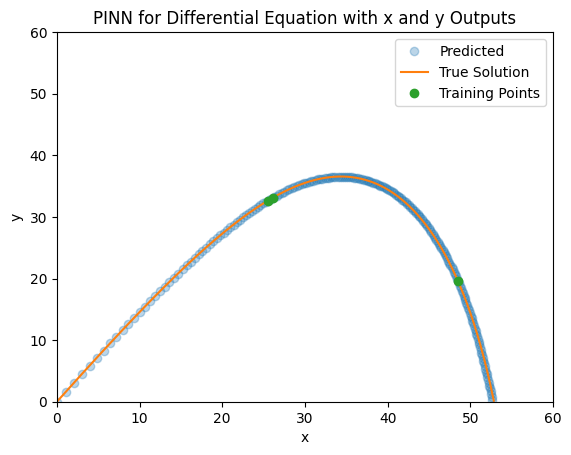

In [298]:
plt.plot( x_pred.detach().numpy(),y_pred.detach().numpy(),'o',alpha=0.3, label='Predicted')
plt.plot( x_sol.detach().numpy(),y_sol.detach().numpy(), label='True Solution')
plt.plot( x_sol_rnd.detach().numpy(),y_sol_rnd.detach().numpy(),'o', label='Training Points')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('PINN for Differential Equation with x and y Outputs')
# Set the y-axis limits 
plt.ylim(0, 60)
plt.xlim(0,60)
plt.show()